In [1]:
!pip install -q roboflow albumentations opencv-python-headless

import os
from roboflow import Roboflow

print("Đang tải dữ liệu sạch từ Roboflow...")
rf = Roboflow(api_key="mclLHXcZODPiI3gS6M3W")
project = rf.workspace("datalables").project("trafficsign2026")
version = project.version(1)
dataset = version.download("yolov8")

# Lưu lại đường dẫn mà Roboflow vừa tải về (Thường nó nằm ở /kaggle/working/trafficsign2026-1)
ROBOFLOW_DIR = dataset.location
print(f"✅ Tải thành công! Dữ liệu nằm tại: {ROBOFLOW_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.7 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
Đang tải dữ liệu sạch từ Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TrafficSign2026-1 in yolov8:: 100%|██████████| 36/36 [00:00<00:00, 6962.46it/s]

✅ Tải thành công! Dữ liệu nằm tại: /kaggle/working/TrafficSign2026-1


In [2]:
import os
import glob
import cv2
import shutil
import albumentations as A
from pathlib import Path

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN & THÔNG SỐ
# ==========================================
# Sửa ROBOFLOW_DIR thành đường dẫn thực tế mà bạn tải về
ROBOFLOW_DIR = "/kaggle/working/TrafficSign2026-1" 

AUGMENTED_DIR = "/kaggle/working/Augmented_2026_Dataset"
AUG_IMAGES_DIR = os.path.join(AUGMENTED_DIR, "images")
AUG_LABELS_DIR = os.path.join(AUGMENTED_DIR, "labels")

shutil.rmtree(AUGMENTED_DIR, ignore_errors=True) 
os.makedirs(AUG_IMAGES_DIR, exist_ok=True)
os.makedirs(AUG_LABELS_DIR, exist_ok=True)

NUM_AUGS_PER_IMAGE = 100
ID_OFFSET = 100 

# ==========================================
# PIPELINE BIẾN ĐỔI (ĐÃ FIX LỖI GAUSSNOISE)
# ==========================================
transform = A.Compose([
    A.Resize(height=640, width=640, p=1.0),           
    A.SafeRotate(limit=15, p=0.7),                    
    A.RandomBrightnessContrast(p=0.8),                
    A.GaussianBlur(blur_limit=(3, 5), p=0.4),         
    A.GaussNoise(p=0.4) # ✅ FIX: Xóa var_limit, để thư viện tự dùng thông số an toàn mặc định
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# ==========================================
# THỰC THI NHÂN BẢN & REMAP ID
# ==========================================
print(f"🚀 Bắt đầu nhân bản... Offset ID: +{ID_OFFSET}")

# Lấy danh sách ảnh từ Roboflow 
roboflow_images = glob.glob(os.path.join(ROBOFLOW_DIR, "**", "*.jpg"), recursive=True)

if len(roboflow_images) == 0:
    print(f"❌ LỖI NGHIÊM TRỌNG: Không tìm thấy ảnh nào trong thư mục {ROBOFLOW_DIR}!")
    print("Bạn hãy check lại chính xác đường dẫn Roboflow lưu dataset nhé.")
else:
    print(f"✅ Tìm thấy {len(roboflow_images)} ảnh gốc. Bắt đầu ép cân & nhân bản...")
    count_total_augs = 0

    for img_path in roboflow_images:
        image = cv2.imread(img_path)
        if image is None: continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Sửa lại cơ chế quét tìm nhãn để tương thích với mọi cấu trúc folder của Roboflow
        label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
        if not os.path.exists(label_path): 
            print(f"⚠️ Bỏ qua ảnh {os.path.basename(img_path)} vì không có file nhãn đi kèm.")
            continue
            
        bboxes = []
        class_labels = []
        
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    new_id = int(parts[0]) + ID_OFFSET
                    class_labels.append(new_id)
                    bboxes.append([float(x) for x in parts[1:]])
                    
        base_name = Path(img_path).stem
        for i in range(NUM_AUGS_PER_IMAGE):
            try:
                transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
                aug_img = transformed['image']
                aug_bboxes = transformed['bboxes']
                aug_labels = transformed['class_labels']
                
                new_img_name = f"{base_name}_aug_{i}.jpg"
                cv2.imwrite(os.path.join(AUG_IMAGES_DIR, new_img_name), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
                
                new_label_name = f"{base_name}_aug_{i}.txt"
                with open(os.path.join(AUG_LABELS_DIR, new_label_name), 'w') as f:
                    for cls, bbox in zip(aug_labels, aug_bboxes):
                        bbox_str = " ".join([f"{x:.6f}" for x in bbox])
                        f.write(f"{cls} {bbox_str}\n")
                        
                count_total_augs += 1
            except Exception as e:
                # Không giấu lỗi nữa, in thẳng ra để check nếu bị lỗi
                print(f"❌ Lỗi biến đổi ở ảnh {base_name}: {e}")
                break # Dừng ngay vòng lặp nếu có lỗi xảy ra để báo cáo

    print("-" * 40)
    print(f"✅ Đã tạo thành công {count_total_augs} ảnh (kích thước 640x640)!")

    # ==========================================
    # ĐÓNG GÓI OUTPUT (ZIP)
    # ==========================================
    zip_output = "/kaggle/working/Dataset_2026_Ready_For_Train"
    print("📦 Đang đóng gói dữ liệu thành file ZIP...")
    shutil.make_archive(zip_output, 'zip', AUGMENTED_DIR)
    print(f"🎉 Hoàn tất! File sẵn sàng cho Notebook 3: {zip_output}.zip")

🚀 Bắt đầu nhân bản... Offset ID: +100
✅ Tìm thấy 15 ảnh gốc. Bắt đầu ép cân & nhân bản...
----------------------------------------
✅ Đã tạo thành công 1500 ảnh (kích thước 640x640)!
📦 Đang đóng gói dữ liệu thành file ZIP...
🎉 Hoàn tất! File sẵn sàng cho Notebook 3: /kaggle/working/Dataset_2026_Ready_For_Train.zip


Đang giải nén tập 2026...
✅ Đang hiển thị ngẫu nhiên 5 ảnh 2026...


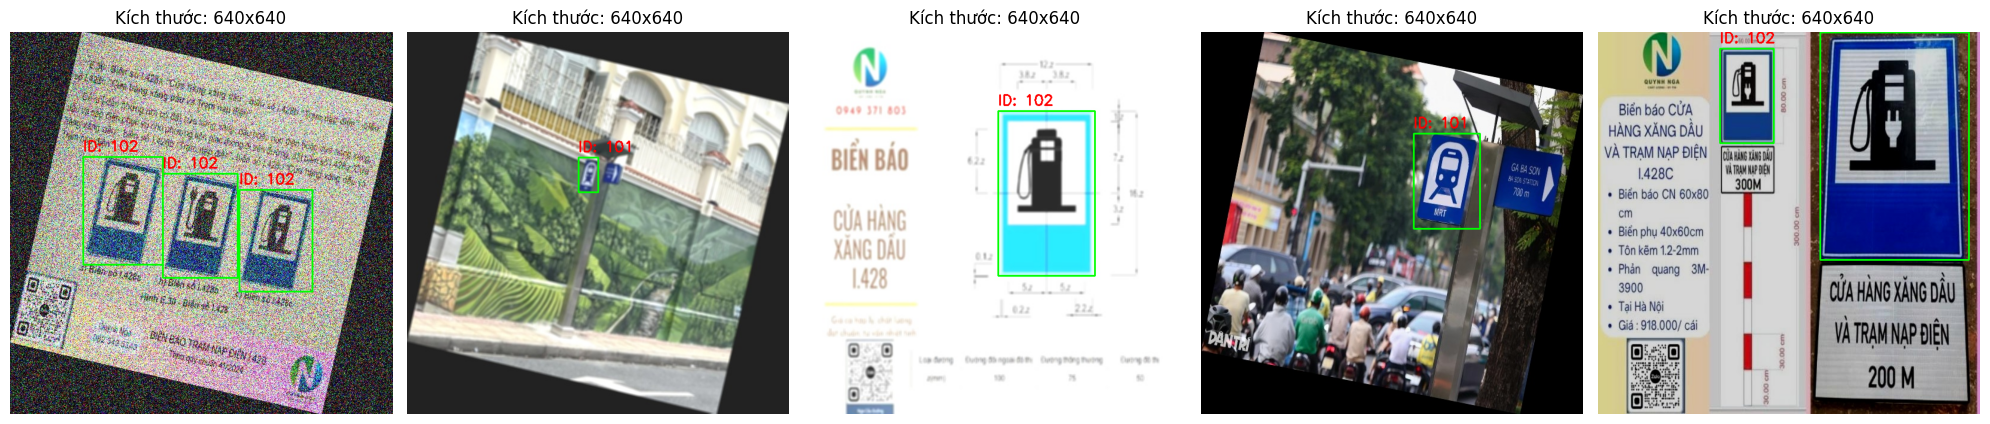

In [3]:
import os
import cv2
import zipfile
import random
import matplotlib.pyplot as plt

# 1. Giải nén tập 2026
zip_path = "/kaggle/working/Dataset_2026_Ready_For_Train.zip"
extract_dir = "/kaggle/working/Dataset_2026_Extracted"

if os.path.exists(zip_path) and not os.path.exists(extract_dir):
    print("Đang giải nén tập 2026...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

def visualize_aug_results(image_dir, label_dir, num_samples=5):
    images = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
    if not images:
        print("❌ Không tìm thấy ảnh!")
        return
        
    samples = random.sample(images, min(num_samples, len(images)))
    plt.figure(figsize=(20, 10))
    
    for i, img_name in enumerate(samples):
        img_path = os.path.join(image_dir, img_name)
        txt_path = os.path.join(label_dir, img_name.replace('.jpg', '.txt'))
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id, xc, yc, bw, bh = map(float, parts)
                        # Giải mã tọa độ YOLO
                        x_min = int((xc - bw/2) * w)
                        y_min = int((yc - bh/2) * h)
                        x_max = int((xc + bw/2) * w)
                        y_max = int((yc + bh/2) * h)
                        
                        # Vẽ Bbox và ghi ID
                        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                        cv2.putText(img, f"ID: {int(class_id)}", (x_min, y_min - 10), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
                        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"Kích thước: {w}x{h}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("✅ Đang hiển thị ngẫu nhiên 5 ảnh 2026...")
visualize_aug_results(os.path.join(extract_dir, "images"), os.path.join(extract_dir, "labels"))

In [4]:
import pandas as pd
import os
import shutil
import ast
from tqdm import tqdm

# 1. CẤU HÌNH ĐƯỜNG DẪN TUYỆT ĐỐI
CSV_PATH = os.path.abspath("/kaggle/input/datasets/phhasian0710/za-traffic-2020/za_traffic_2020/traffic_train/annotation.csv")
LABELS_2020_CONVERTED = os.path.abspath("/kaggle/working/labels_2020_converted")

# Xóa và tạo lại thư mục
if os.path.exists(LABELS_2020_CONVERTED):
    shutil.rmtree(LABELS_2020_CONVERTED)
os.makedirs(LABELS_2020_CONVERTED, exist_ok=True)

# 2. ĐỌC CSV VÀ KIỂM TRA
print("Đang đọc file annotation.csv...")
df = pd.read_csv(CSV_PATH)

class_col = 'category_id'
if 'bbox' not in df.columns:
    raise Exception("❌ KHÔNG TÌM THẤY CỘT 'bbox'!")

# 3. ÉP GHI (FORCE WRITE) TOÀN BỘ FILE
# Chúng ta group theo 'file_name' (ví dụ: '123.png') cho chuẩn xác nhất
grouped = df.groupby('file_name')
print("\n🚀 Bắt đầu Force Write nhãn 2020 từ mảng bbox...")

for file_name, group in tqdm(grouped):
    # Lấy tên file gốc bỏ đuôi (VD: '123.png' -> '123')
    clean_name = str(file_name).split('.')[0]
    
    yolo_lines = []
    for _, row in group.iterrows():
        class_id = int(row[class_col])
        
        # Parse mảng bbox. Dạng COCO chuẩn là [x_min, y_min, width, height]
        bbox_str = row['bbox']
        if isinstance(bbox_str, str):
            bbox = ast.literal_eval(bbox_str) # Biến string '[x, y, w, h]' thành list thật
        else:
            bbox = bbox_str
            
        x_min, y_min, box_w, box_h = bbox
        
        # Lấy kích thước gốc của ảnh ĐỘNG từ chính file CSV
        img_w = float(row['width'])
        img_h = float(row['height'])
        
        # Chuyển đổi sang tỷ lệ 0-1 chuẩn YOLO
        x_center = (x_min + box_w / 2.0) / img_w
        y_center = (y_min + box_h / 2.0) / img_h
        norm_w = box_w / img_w
        norm_h = box_h / img_h
        
        # Rào lỗi tọa độ bị âm hoặc lọt ra ngoài khung hình (rất hay gặp ở dataset làm ẩu)
        x_center = max(0.0, min(1.0, x_center))
        y_center = max(0.0, min(1.0, y_center))
        norm_w = max(0.0, min(1.0, norm_w))
        norm_h = max(0.0, min(1.0, norm_h))
        
        yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}")
        
    # Ghi thẳng ra đĩa cứng
    txt_path = os.path.join(LABELS_2020_CONVERTED, f"{clean_name}.txt")
    with open(txt_path, 'w') as f:
        f.write("\n".join(yolo_lines))

# 4. LỆNH HẬU KIỂM
actual_files = len(os.listdir(LABELS_2020_CONVERTED))
print(f"\n✅ Thực tế trong folder có: {actual_files} file.")

if actual_files == 0:
    raise Exception("❌ LỖI NGHIÊM TRỌNG: 0 file được tạo ra!")

Đang đọc file annotation.csv...

🚀 Bắt đầu Force Write nhãn 2020 từ mảng bbox...


100%|██████████| 4500/4500 [00:01<00:00, 2609.92it/s]


✅ Thực tế trong folder có: 4500 file.


In [5]:
import cv2
import numpy as np
import os
from pathlib import Path
from tqdm import tqdm

# Cấu hình đường dẫn
IMAGES_2020_DIR = os.path.abspath("/kaggle/input/datasets/phhasian0710/za-traffic-2020/za_traffic_2020/traffic_train/images")
LABELS_2020_CONVERTED = os.path.abspath("/kaggle/working/labels_2020_converted")
TILED_IMAGES_DIR = os.path.abspath("/kaggle/working/tiled_2020/images")
TILED_LABELS_DIR = os.path.abspath("/kaggle/working/tiled_2020/labels")

os.makedirs(TILED_IMAGES_DIR, exist_ok=True)
os.makedirs(TILED_LABELS_DIR, exist_ok=True)

# 1. DEBUG ĐƯỜNG DẪN: Xem thực tế ảnh và nhãn có gì
print("=== 🔍 DEBUG ĐƯỜNG DẪN ===")
sample_labels = os.listdir(LABELS_2020_CONVERTED)[:5]
print(f"👉 5 Nhãn đầu tiên: {sample_labels}")

# Tìm thử 5 file ảnh đầu tiên (quét sâu vào các thư mục con)
sample_images = list(Path(IMAGES_2020_DIR).rglob("*.*"))[:5]
print(f"👉 5 Ảnh đầu tiên: {[f.name for f in sample_images]}")
print("-" * 40)

# Khởi tạo biến
original_areas = []
tiled_areas = []
total_tiles = 0

txt_files = [f for f in os.listdir(LABELS_2020_CONVERTED) if f.endswith('.txt')]
print(f"🚀 Bắt đầu Rọc ảnh & Phân tích diện tích cho {len(txt_files)} file...")

slice_size = 640
overlap = 0.2
step = int(slice_size * (1 - overlap))

# Để biến lưu lại số lần lỗi
error_count = 0

for txt_name in tqdm(txt_files[:500]):
    # Xử lý tên file siêu sạch (VD: '123.png.txt' -> '123')
    base_id = Path(txt_name).stem.split('.')[0]
    
    # 2. LOGIC TÌM ẢNH THÔNG MINH (Quét toàn bộ thư mục con)
    # Tìm bất kỳ file nào có tên là base_id, không quan tâm đuôi
    found_images = list(Path(IMAGES_2020_DIR).rglob(f"{base_id}.*"))
    
    # Lọc chỉ lấy file ảnh thực sự
    valid_exts = ['.png', '.jpg', '.jpeg', '.webp']
    valid_images = [img for img in found_images if img.suffix.lower() in valid_exts]
    
    if not valid_images:
        # CẢNH BÁO NẾU KHÔNG TÌM THẤY ẢNH (Chỉ in 5 lỗi đầu để tránh spam)
        error_count += 1
        if error_count <= 5:
            print(f"\n❌ LỖI: Không tìm thấy ảnh gốc cho nhãn: {txt_name} (ID tìm kiếm: {base_id})")
        continue

    # Lấy ảnh đầu tiên tìm được
    img_path = str(valid_images[0])

    img = cv2.imread(img_path)
    if img is None: continue
    img_h, img_w = img.shape[:2]
    
    bboxes = []
    with open(os.path.join(LABELS_2020_CONVERTED, txt_name), 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                bw, bh = float(parts[3]), float(parts[4])
                original_areas.append(bw * bh)
                bboxes.append([int(parts[0]), float(parts[1]), float(parts[2]), bw, bh])
                
    # Bắt đầu Tiling
    for y in range(0, img_h, step):
        for x in range(0, img_w, step):
            y1, y2 = y, min(y + slice_size, img_h)
            x1, x2 = x, min(x + slice_size, img_w)
            
            crop_img = np.zeros((slice_size, slice_size, 3), dtype=np.uint8)
            crop_img[0:y2-y1, 0:x2-x1] = img[y1:y2, x1:x2]
            
            valid_bboxes = []
            for box in bboxes:
                cls_id, xc, yc, bw, bh = box
                px_xmin, px_ymin = (xc - bw/2) * img_w, (yc - bh/2) * img_h
                px_xmax, px_ymax = (xc + bw/2) * img_w, (yc + bh/2) * img_h
                
                inter_xmin, inter_ymin = max(px_xmin, x1), max(px_ymin, y1)
                inter_xmax, inter_ymax = min(px_xmax, x2), min(px_ymax, y2)
                
                if inter_xmin < inter_xmax and inter_ymin < inter_ymax:
                    new_xc = ((inter_xmin + inter_xmax) / 2 - x1) / slice_size
                    new_yc = ((inter_ymin + inter_ymax) / 2 - y1) / slice_size
                    new_w = (inter_xmax - inter_xmin) / slice_size
                    new_h = (inter_ymax - inter_ymin) / slice_size
                    
                    valid_bboxes.append(f"{cls_id} {new_xc:.6f} {new_yc:.6f} {new_w:.6f} {new_h:.6f}")
                    tiled_areas.append(new_w * new_h)
            
            if valid_bboxes:
                tile_name = f"{base_id}_tile_{x}_{y}"
                cv2.imwrite(os.path.join(TILED_IMAGES_DIR, tile_name + ".jpg"), crop_img)
                with open(os.path.join(TILED_LABELS_DIR, tile_name + ".txt"), 'w') as f:
                    f.write("\n".join(valid_bboxes))
                total_tiles += 1

print("\n=== 📊 BÁO CÁO HIỆU QUẢ TILING ===")
if original_areas and tiled_areas:
    avg_orig = np.mean(original_areas) * 100
    avg_tiled = np.mean(tiled_areas) * 100
    growth = avg_tiled / avg_orig if avg_orig > 0 else 0
    
    print(f"👉 Diện tích biển báo TRƯỚC TILING: {avg_orig:.4f}% so với ảnh gốc.")
    print(f"👉 Diện tích biển báo SAU TILING:   {avg_tiled:.4f}% so với block 640x640.")
    print(f"📈 KẾT LUẬN: Biển báo đã 'to' lên gấp {growth:.1f} lần trong mắt Model!")
else:
    print("⚠️ Không thu thập được dữ liệu diện tích. Có thể quá trình Tiling đã lỗi hoàn toàn.")
    print(f"Tổng số lỗi không tìm thấy ảnh: {error_count}/{len(txt_files[:500])}")
    
print(f"✅ Hoàn tất! Đã lưu {total_tiles} block ảnh chứa biển báo.")

=== 🔍 DEBUG ĐƯỜNG DẪN ===
👉 5 Nhãn đầu tiên: ['6430.txt', '9323.txt', '5671.txt', '1528.txt', '10779.txt']
👉 5 Ảnh đầu tiên: ['9292.png', '4353.png', '5511.png', '8419.png', '9110.png']
----------------------------------------
🚀 Bắt đầu Rọc ảnh & Phân tích diện tích cho 4500 file...


100%|██████████| 500/500 [00:55<00:00,  8.97it/s]


=== 📊 BÁO CÁO HIỆU QUẢ TILING ===
👉 Diện tích biển báo TRƯỚC TILING: 0.1093% so với ảnh gốc.
👉 Diện tích biển báo SAU TILING:   0.2566% so với block 640x640.
📈 KẾT LUẬN: Biển báo đã 'to' lên gấp 2.3 lần trong mắt Model!
✅ Hoàn tất! Đã lưu 784 block ảnh chứa biển báo.


In [6]:
import cv2
import numpy as np
import os
from pathlib import Path
from tqdm import tqdm

# Cấu hình đường dẫn
IMAGES_2020_DIR = os.path.abspath("/kaggle/input/datasets/phhasian0710/za-traffic-2020/za_traffic_2020/traffic_train/images")
LABELS_2020_CONVERTED = os.path.abspath("/kaggle/working/labels_2020_converted")
TILED_IMAGES_DIR = os.path.abspath("/kaggle/working/tiled_2020/images")
TILED_LABELS_DIR = os.path.abspath("/kaggle/working/tiled_2020/labels")

os.makedirs(TILED_IMAGES_DIR, exist_ok=True)
os.makedirs(TILED_LABELS_DIR, exist_ok=True)

txt_files = [f for f in os.listdir(LABELS_2020_CONVERTED) if f.endswith('.txt')]

# --- LOGIC RESUME THÔNG MINH ---
existing_tiles = os.listdir(TILED_IMAGES_DIR)
# Lấy danh sách các ID gốc đã được cắt thành công từ trước
processed_bases = set([f.split('_tile_')[0] for f in existing_tiles if '_tile_' in f])

print(f"🚀 Bắt đầu Rọc ảnh FULL ({len(txt_files)} file)...")
print(f"👉 Hệ thống ghi nhận đã có {len(processed_bases)} ảnh gốc được xử lý từ trước. Sẽ tự động bỏ qua để tiết kiệm thời gian!")

slice_size = 640
overlap = 0.2
step = int(slice_size * (1 - overlap))
total_tiles = len(existing_tiles)

# Chạy FULL dataset (đã gỡ [:500])
for txt_name in tqdm(txt_files):
    base_id = Path(txt_name).stem.split('.')[0]
    
    # BỎ QUA NẾU ĐÃ XỬ LÝ (Resume Capability)
    if base_id in processed_bases:
        continue
        
    # TÌM ẢNH THÔNG MINH
    found_images = list(Path(IMAGES_2020_DIR).rglob(f"{base_id}.*"))
    valid_exts = ['.png', '.jpg', '.jpeg', '.webp']
    valid_images = [img for img in found_images if img.suffix.lower() in valid_exts]
    
    if not valid_images:
        continue

    img_path = str(valid_images[0])
    img = cv2.imread(img_path)
    if img is None: continue
    img_h, img_w = img.shape[:2]
    
    bboxes = []
    with open(os.path.join(LABELS_2020_CONVERTED, txt_name), 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                bboxes.append([int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
                
    # Bắt đầu Tiling
    for y in range(0, img_h, step):
        for x in range(0, img_w, step):
            y1, y2 = y, min(y + slice_size, img_h)
            x1, x2 = x, min(x + slice_size, img_w)
            
            crop_img = np.zeros((slice_size, slice_size, 3), dtype=np.uint8)
            crop_img[0:y2-y1, 0:x2-x1] = img[y1:y2, x1:x2]
            
            valid_bboxes = []
            for box in bboxes:
                cls_id, xc, yc, bw, bh = box
                px_xmin, px_ymin = (xc - bw/2) * img_w, (yc - bh/2) * img_h
                px_xmax, px_ymax = (xc + bw/2) * img_w, (yc + bh/2) * img_h
                
                inter_xmin, inter_ymin = max(px_xmin, x1), max(px_ymin, y1)
                inter_xmax, inter_ymax = min(px_xmax, x2), min(px_ymax, y2)
                
                if inter_xmin < inter_xmax and inter_ymin < inter_ymax:
                    new_xc = ((inter_xmin + inter_xmax) / 2 - x1) / slice_size
                    new_yc = ((inter_ymin + inter_ymax) / 2 - y1) / slice_size
                    new_w = (inter_xmax - inter_xmin) / slice_size
                    new_h = (inter_ymax - inter_ymin) / slice_size
                    
                    valid_bboxes.append(f"{cls_id} {new_xc:.6f} {new_yc:.6f} {new_w:.6f} {new_h:.6f}")
            
            if valid_bboxes:
                tile_name = f"{base_id}_tile_{x}_{y}"
                cv2.imwrite(os.path.join(TILED_IMAGES_DIR, tile_name + ".jpg"), crop_img)
                with open(os.path.join(TILED_LABELS_DIR, tile_name + ".txt"), 'w') as f:
                    f.write("\n".join(valid_bboxes))
                total_tiles += 1

print(f"\n✅ Hoàn tất FULL Tiling! Tổng cộng đang có {total_tiles} block ảnh 640x640 sẵn sàng.")

🚀 Bắt đầu Rọc ảnh FULL (4500 file)...
👉 Hệ thống ghi nhận đã có 500 ảnh gốc được xử lý từ trước. Sẽ tự động bỏ qua để tiết kiệm thời gian!


100%|██████████| 4500/4500 [05:44<00:00, 13.04it/s] 


✅ Hoàn tất FULL Tiling! Tổng cộng đang có 6949 block ảnh 640x640 sẵn sàng.


In [13]:
import os
import random

TILED_IMAGES_DIR = "/kaggle/working/tiled_2020/images"
AUG_IMAGES_DIR = "/kaggle/working/Augmented_2026_Dataset/images"

# 1. Thu thập toàn bộ đường dẫn
tiled_2020_imgs = [os.path.join(TILED_IMAGES_DIR, f) for f in os.listdir(TILED_IMAGES_DIR) if f.endswith('.jpg')]
aug_2026_imgs = [os.path.join(AUG_IMAGES_DIR, f) for f in os.listdir(AUG_IMAGES_DIR) if f.endswith('.jpg')] if os.path.exists(AUG_IMAGES_DIR) else []

all_final_images = tiled_2020_imgs + aug_2026_imgs

# 2. Trộn ngẫu nhiên (Shuffle) và chia 80/20
random.shuffle(all_final_images)
split_idx = int(len(all_final_images) * 0.8)

train_list = all_final_images[:split_idx]
val_list = all_final_images[split_idx:]

with open('/kaggle/working/train.txt', 'w') as f:
    f.write('\n'.join(train_list))
with open('/kaggle/working/val.txt', 'w') as f:
    f.write('\n'.join(val_list))

# 3. Tạo file YAML cấu hình cực chuẩn
yaml_content = f"""
train: /kaggle/working/train.txt
val: /kaggle/working/val.txt

nc: 103

names:
"""
# Map 0-99 cho Zalo 2020
for i in range(100):
    yaml_content += f"  {i}: 'Zalo_Class_{i}'\n"
# Map 100-102 cho 2026
yaml_content += f"  100: 'LED'\n  101: 'Metro'\n  102: 'TramSac'\n"

with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(yaml_content.strip())

# 4. HẬU KIỂM CUỐI CÙNG
total_images = len(all_final_images)
print("=== BÁO CÁO HỢP NHẤT DỮ LIỆU ===")
print(f"👉 Ảnh tập 2020 (Tiled): {len(tiled_2020_imgs)}")
print(f"👉 Ảnh tập 2026 (Augmented): {len(aug_2026_imgs)}")
print(f"👉 Chia tỷ lệ: Train ({len(train_list)} ảnh) - Val ({len(val_list)} ảnh)")
print("-" * 40)
print(f"🔥 Tổng số ảnh Model sẽ 'ăn': {total_images}")

if total_images > 5000:
    print("\n🚀 HỆ THỐNG SẴN SÀNG KHAI HỎA!")
else:
    print("\n⚠️ Tổng số ảnh chưa đạt 5000, nhưng vẫn có thể bắt đầu train để test pipeline.")

=== BÁO CÁO HỢP NHẤT DỮ LIỆU ===
👉 Ảnh tập 2020 (Tiled): 6949
👉 Ảnh tập 2026 (Augmented): 1500
👉 Chia tỷ lệ: Train (6759 ảnh) - Val (1690 ảnh)
----------------------------------------
🔥 Tổng số ảnh Model sẽ 'ăn': 8449

🚀 HỆ THỐNG SẴN SÀNG KHAI HỎA!


In [14]:
# Cài đặt thư viện Ultralytics (YOLOv8) nếu chưa có
!pip install -q ultralytics

from ultralytics import YOLO

print("Đang khởi tạo Model YOLOv8 Nano...")
# Load một pretrained model nhỏ gọn để học nhanh trên Kaggle
model = YOLO('yolov8n.pt') 

print("🚀 BẮT ĐẦU HUẤN LUYỆN (TRAINING)...")
# Cấu hình siêu tham số đúng chuẩn yêu cầu
results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0, # Bắt buộc chạy trên GPU 0
    name='traffic_sign_2026_model', # Tên folder lưu kết quả
    cache=False # Tắt cache để tránh quá tải RAM của Kaggle
)

print("✅ Huấn luyện hoàn tất! Trọng số tốt nhất đã được lưu trong thư mục: runs/detect/traffic_sign_2026_model/weights/best.pt")

Đang khởi tạo Model YOLOv8 Nano...
🚀 BẮT ĐẦU HUẤN LUYỆN (TRAINING)...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_sign_2026_model2, nbs=64, nms=False, opset=

In [25]:
import os
import shutil
import time
from IPython.display import FileLink, display

# Chốt chặn đường dẫn chính xác của bạn là model2
exp_dir = "/kaggle/working/runs/detect/traffic_sign_2026_model2"
zip_full_path = "/kaggle/working/Ket_Qua_Final_Model2.zip"

if os.path.exists(exp_dir):
    # Xóa file zip cũ nếu có để tránh trùng lặp
    if os.path.exists(zip_full_path):
        os.remove(zip_full_path)
    
    print(f"📦 Đang đóng gói thư mục: {exp_dir}")
    shutil.make_archive(zip_full_path.replace('.zip', ''), 'zip', exp_dir)
    
    # Đợi 2 giây để hệ thống file cập nhật
    time.sleep(2)
    
    if os.path.exists(zip_full_path):
        print("✅ Nén thành công! Thử click vào link dưới đây:")
        # Dùng FileLink với đường dẫn tương đối để tránh lỗi 404
        display(FileLink(os.path.relpath(zip_full_path, "/kaggle/working")))
    else:
        print("❌ Lỗi: File Zip không được tạo ra.")
else:
    print(f"❌ Không tìm thấy thư mục: {exp_dir}. Hãy kiểm tra lại tên folder trong runs/detect/")

📦 Đang đóng gói thư mục: /kaggle/working/runs/detect/traffic_sign_2026_model2
✅ Nén thành công! Thử click vào link dưới đây:


/kaggle/working/Ket_Qua_Final_Model2.zip

⏳ Đang load trọng số (weights) tốt nhất từ: /kaggle/working/runs/detect/traffic_sign_2026_model2/weights/best.pt
✅ Load Model YOLOv8 thành công!

🚀 Bắt đầu Inference trên 6 ảnh ngẫu nhiên từ tập Validation...


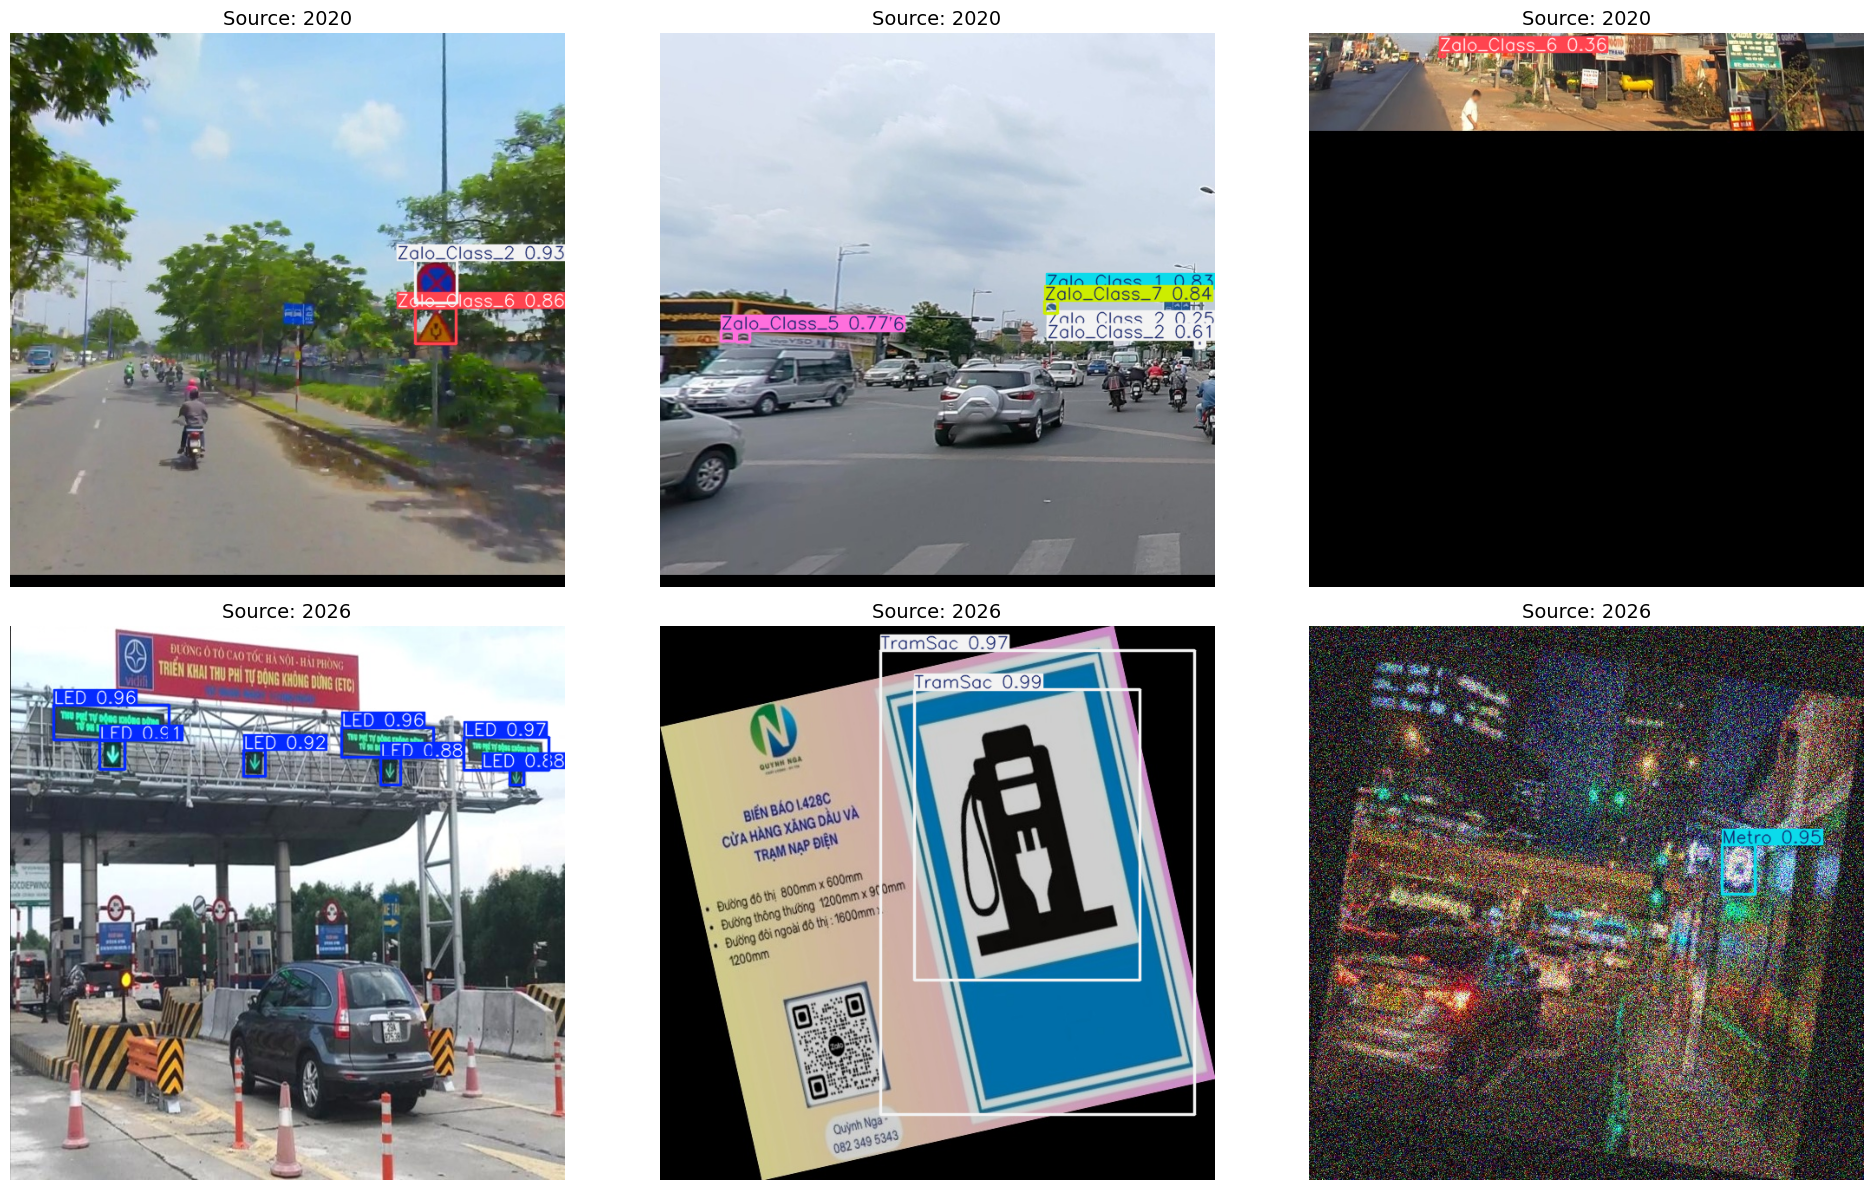


📊 HIỂN THỊ BIỂU ĐỒ ĐÁNH GIÁ (EVALUATION CHARTS)...


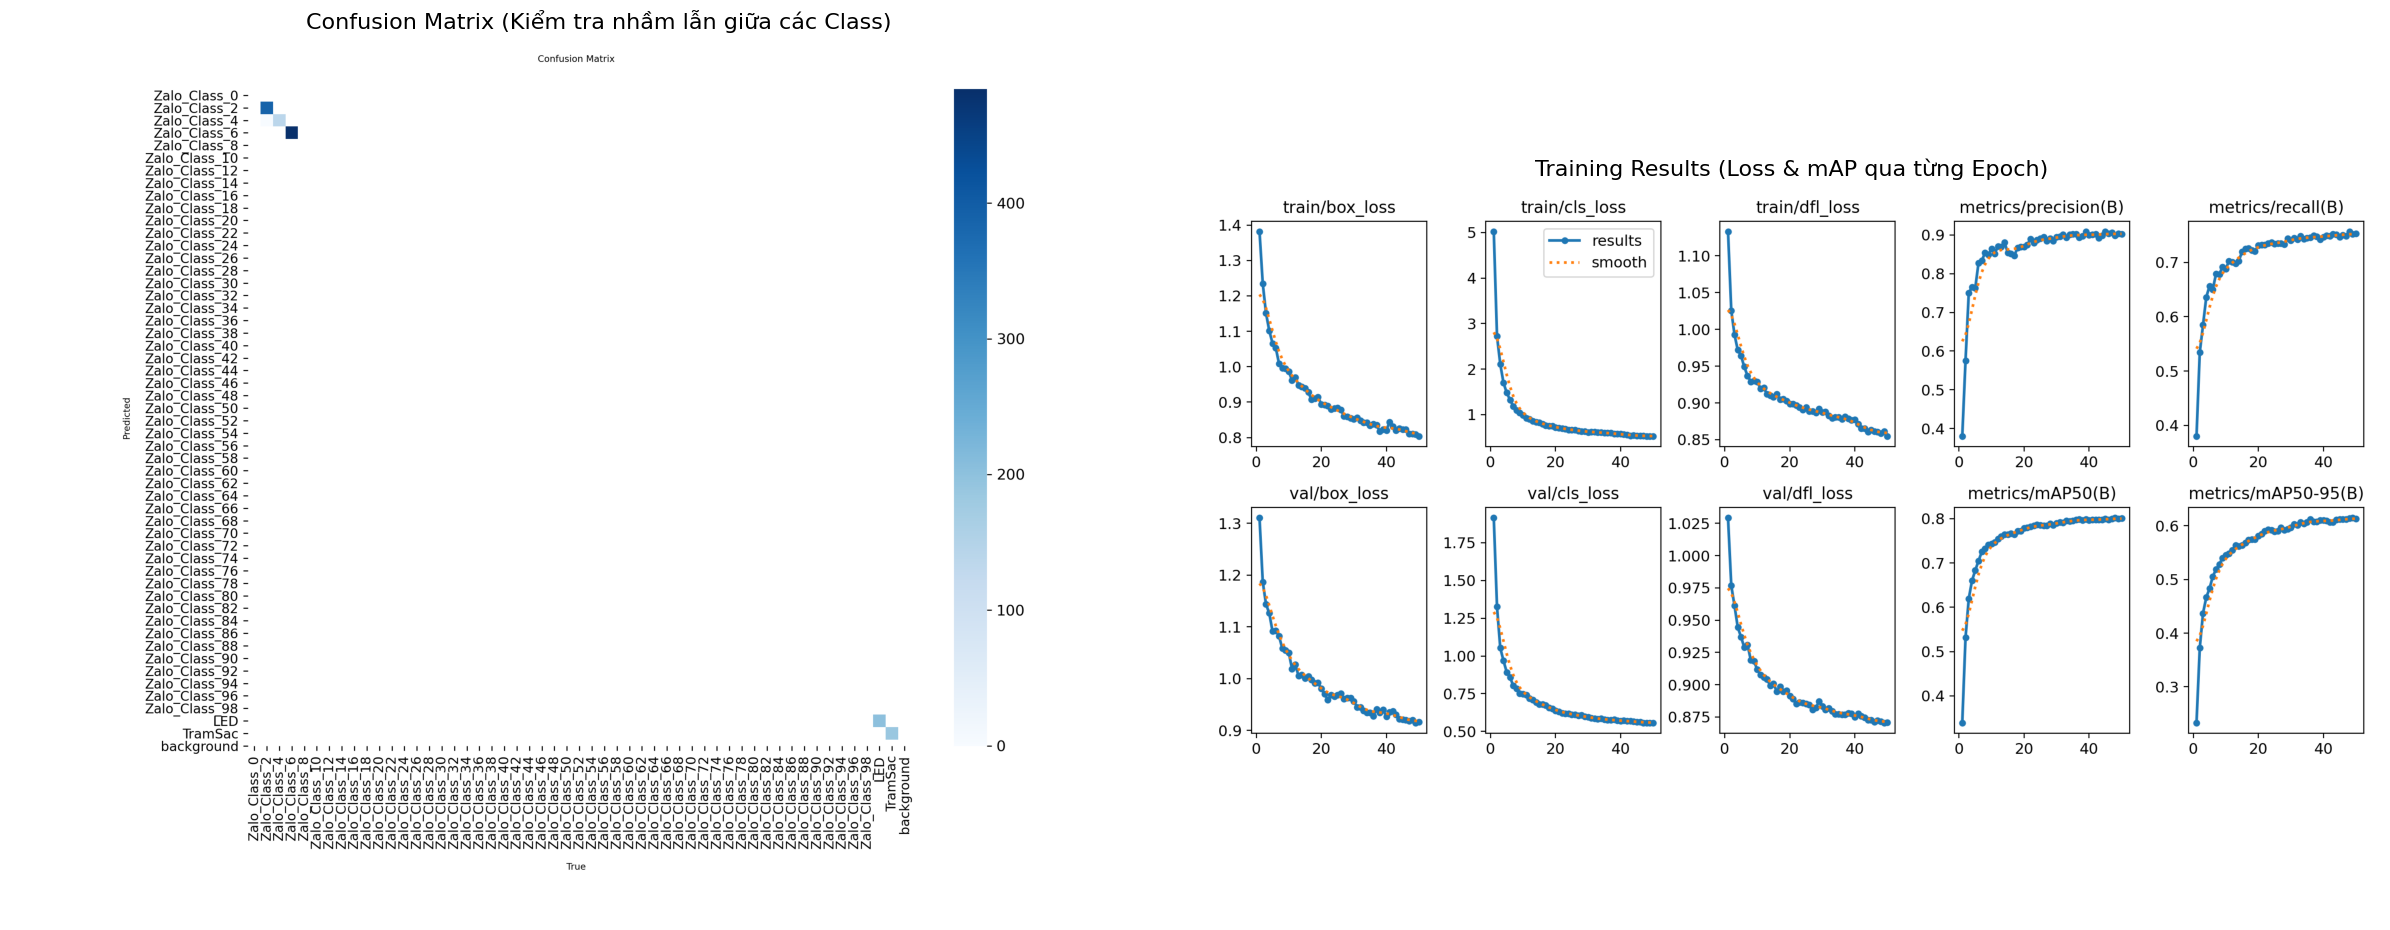


=== 🔍 KIỂM TRA OVERFITTING BẰNG SỐ LIỆU ===
👉 Box Loss tập Train: 0.8032
👉 Box Loss tập Val:   0.9167
👉 Final mAP50:        0.8006
✅ NHẬN XÉT TUYỆT VỜI: Khoảng cách giữa Train Loss và Val Loss rất hẹp. Model tổng quát hóa (Generalize) rất tốt, hoàn toàn không bị Overfitting nặng!


In [24]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# 1. Định nghĩa 2 luồng xử lý ảnh RIÊNG BIỆT
# Luồng Train: Cố tình làm khó model (Xoay, đổi màu, thêm nhiễu)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15), # Xoay ngẫu nhiên
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Đổi độ sáng/tương phản
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Luồng Val (Thi cử): Tuyệt đối giữ nguyên bản, chỉ Resize và Normalize
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Tạo 2 Dataset trỏ về CÙNG MỘT thư mục gốc (chỉ chứa ảnh crop nguyên bản, xóa sạch ảnh đã augment lưu trên đĩa)
CNN_DATASET_DIR = "/kaggle/working/cnn_dataset/train" # Thư mục này giờ chỉ nên chứa ảnh Crop gốc
full_train_dataset = datasets.ImageFolder(root=CNN_DATASET_DIR, transform=train_transform)
full_val_dataset = datasets.ImageFolder(root=CNN_DATASET_DIR, transform=val_transform)

# 3. Chia index 80/20 cực chuẩn (Không để lọt index qua lại)
num_samples = len(full_train_dataset)
indices = list(range(num_samples))
np.random.shuffle(indices)
split = int(np.floor(0.2 * num_samples))

train_idx, val_idx = indices[split:], indices[:split]

# 4. Gắn Index vào đúng Dataset
train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_val_dataset, val_idx)

# Nạp vào DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"✅ Setup an toàn: Train ({len(train_dataset)} ảnh có Augment) - Val ({len(val_dataset)} ảnh nguyên bản)")